# Colab Session: 4804a5
Generated from colab-cli history log.

**Session Created**: 2026-09-27 16:16:51
- Endpoint: `m-s-kkb-use1d2-1nyp2k85qor3q`
- Hardware: `NONE`

In [ ]:
import pandas as pd
import numpy as np

# Bisa juga pakai file lokal: ../data/healthcare-stroke-data.csv
URL_DATA = "https://raw.githubusercontent.com/ravi-arnan/machine-learning/main/data/healthcare-stroke-data.csv"
df = pd.read_csv(URL_DATA)

print("Dataset berhasil dimuat.")
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])


Dataset berhasil dimuat.
Jumlah baris : 5110
Jumlah kolom : 12


In [ ]:
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
deskripsi = {
    "id": "Nomor identitas unik pasien (tidak dipakai prediksi)",
    "gender": "Jenis kelamin: Male, Female, Other",
    "age": "Usia pasien dalam tahun",
    "hypertension": "Riwayat hipertensi: 0 = tidak, 1 = ya (sudah angka biner)",
    "heart_disease": "Riwayat penyakit jantung: 0 = tidak, 1 = ya (angka biner)",
    "ever_married": "Pernah menikah: Yes / No",
    "work_type": "Tipe pekerjaan: Private, Self-employed, Govt_job, children, Never_worked",
    "Residence_type": "Tipe tempat tinggal: Urban / Rural",
    "avg_glucose_level": "Kadar glukosa rata-rata dalam darah",
    "bmi": "Indeks massa tubuh",
    "smoking_status": "Status merokok: formerly smoked, never smoked, smokes, Unknown",
    "stroke": "Label target: 0 = tidak stroke, 1 = stroke (angka biner)",
}

for kolom, arti in deskripsi.items():
    print(f"  {kolom:20s} -> {arti}")


  id                   -> Nomor identitas unik pasien (tidak dipakai prediksi)
  gender               -> Jenis kelamin: Male, Female, Other
  age                  -> Usia pasien dalam tahun
  hypertension         -> Riwayat hipertensi: 0 = tidak, 1 = ya (sudah angka biner)
  heart_disease        -> Riwayat penyakit jantung: 0 = tidak, 1 = ya (angka biner)
  ever_married         -> Pernah menikah: Yes / No
  work_type            -> Tipe pekerjaan: Private, Self-employed, Govt_job, children, Never_worked
  Residence_type       -> Tipe tempat tinggal: Urban / Rural
  avg_glucose_level    -> Kadar glukosa rata-rata dalam darah
  bmi                  -> Indeks massa tubuh
  smoking_status       -> Status merokok: formerly smoked, never smoked, smokes, Unknown
  stroke               -> Label target: 0 = tidak stroke, 1 = stroke (angka biner)


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
def cari_data_kosong(dataframe):
    """Loop tiap kolom, cetak kolom yang punya NaN."""
    print("=" * 50)
    print("PEMERIKSAAN DATA KOSONG")
    print("=" * 50)
    
    total_baris = len(dataframe)
    ada_kosong = False
    
    for kolom in dataframe.columns:
        jumlah = dataframe[kolom].isna().sum()
        if jumlah > 0:
            persen = (jumlah / total_baris) * 100
            print(f"  {kolom}: {jumlah} baris kosong ({persen:.2f}%)")
            ada_kosong = True
    
    if not ada_kosong:
        print("  Tidak ada data kosong.")
    print("=" * 50)

cari_data_kosong(df)


PEMERIKSAAN DATA KOSONG
  bmi: 201 baris kosong (3.93%)


In [ ]:
def cari_nilai_tersembunyi(dataframe):
    """Loop kolom teks, cari nilai yang kemungkinan adalah missing value tersamar."""
    print("=" * 50)
    print("NILAI KOSONG TERSEMBUNYI")
    print("=" * 50)
    
    nilai_curiga = ["Unknown", "unknown", "N/A", "NA", "?", "-", ""]
    total_baris = len(dataframe)
    ditemukan = False
    
    for kolom in dataframe.columns:
        if not pd.api.types.is_string_dtype(dataframe[kolom]):
            continue
        for nilai in nilai_curiga:
            jumlah = (dataframe[kolom] == nilai).sum()
            if jumlah > 0:
                persen = (jumlah / total_baris) * 100
                print(f"  {kolom}: {jumlah} baris ({persen:.2f}%) berisi '{nilai}'")
                ditemukan = True
    
    if not ditemukan:
        print("  Tidak ada nilai tersembunyi yang mencurigakan.")
    print("=" * 50)

cari_nilai_tersembunyi(df)


NILAI KOSONG TERSEMBUNYI
  smoking_status: 1544 baris (30.22%) berisi 'Unknown'


In [ ]:
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.83,21161.72,67.00,17741.25,36932.00,54682.00,72940.00
age,5110.0,43.23,22.61,0.08,25.00,45.00,61.00,82.00
hypertension,5110.0,0.10,0.30,0.00,0.00,0.00,0.00,1.00
heart_disease,5110.0,0.05,0.23,0.00,0.00,0.00,0.00,1.00
avg_glucose_level,5110.0,106.15,45.28,55.12,77.24,91.88,114.09,271.74
bmi,4909.0,28.89,7.85,10.30,23.50,28.10,33.10,97.60
stroke,5110.0,0.05,0.22,0.00,0.00,0.00,0.00,1.00


In [ ]:
def cari_duplikat(dataframe):
    """Cek duplikat baris dan ID."""
    print("=" * 50)
    print("PEMERIKSAAN DUPLIKAT")
    print("=" * 50)

    # Duplikat baris penuh via duplicated()
    total = dataframe.duplicated().sum()
    print(f"  Baris duplikat (penuh): {total}")

    if "id" in dataframe.columns:
        duplikat_id = dataframe["id"].duplicated().sum()
        unik = dataframe["id"].nunique()
        print(f"  ID duplikat: {duplikat_id}")
        print(f"  ID unik: {unik} dari {len(dataframe)} baris")
    print("=" * 50)

cari_duplikat(df)


PEMERIKSAAN DUPLIKAT
  Baris duplikat (penuh): 0
  ID duplikat: 0
  ID unik: 5110 dari 5110 baris


In [ ]:
for kolom in df.columns:
    if not pd.api.types.is_string_dtype(df[kolom]):
        continue
    print(f"--- {kolom} ---")
    print(df[kolom].value_counts().to_string())
    print()


--- gender ---
gender
Female    2994
Male      2115
Other        1

--- ever_married ---
ever_married
Yes    3353
No     1757

--- work_type ---
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22

--- Residence_type ---
Residence_type
Urban    2596
Rural    2514

--- smoking_status ---
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789



In [ ]:
jumlah = df["stroke"].value_counts()
persen = (jumlah / len(df) * 100).round(2)

print("Distribusi kelas target (stroke):")
print(f"  0 (Tidak stroke): {jumlah[0]} ({persen[0]}%)")
print(f"  1 (Stroke):       {jumlah[1]} ({persen[1]}%)")
print(f"  Rasio: {jumlah[0]/jumlah[1]:.1f} : 1")


Distribusi kelas target (stroke):
  0 (Tidak stroke): 4861 (95.13%)
  1 (Stroke):       249 (4.87%)
  Rasio: 19.5 : 1


In [ ]:
print("Rentang nilai tiap kolom numerik:")
for kolom in df.select_dtypes(include="number").columns:
    print(f"  {kolom}: {df[kolom].min()} - {df[kolom].max()}")

print()
print("Kasus mencurigakan:")
if "bmi" in df.columns:
    print(f"  BMI > 60: {(df['bmi'] > 60).sum()} baris")
print(f"  Usia < 2 tahun: {(df['age'] < 2).sum()} baris")
if "gender" in df.columns:
    print(f"  gender = 'Other': {(df['gender'] == 'Other').sum()} baris")


Rentang nilai tiap kolom numerik:
  id: 67 - 72940
  age: 0.08 - 82.0
  hypertension: 0 - 1
  heart_disease: 0 - 1
  avg_glucose_level: 55.12 - 271.74
  bmi: 10.3 - 97.6
  stroke: 0 - 1

Kasus mencurigakan:
  BMI > 60: 13 baris
  Usia < 2 tahun: 120 baris
  gender = 'Other': 1 baris


In [ ]:
# Baris dengan BMI sangat tinggi untuk diperiksa
df[df["bmi"] > 60][["age", "bmi", "avg_glucose_level", "stroke"]]


,age,bmi,avg_glucose_level,stroke
270,57.0,60.9,129.54,0
358,52.0,64.8,78.40,0
466,61.0,60.2,170.05,0
544,42.0,71.9,210.48,0
928,23.0,78.0,70.03,0
1559,53.0,66.8,72.63,0
2128,17.0,97.6,61.67,0
2764,24.0,63.3,85.55,0
2840,52.0,61.2,98.27,0
3825,52.0,61.6,118.46,0


In [ ]:
# Kolom identitas tidak dipakai untuk prediksi
KOLOM_ID = "id"
KOLOM_TARGET = "stroke"
kolom_fitur = [k for k in df.columns if k not in (KOLOM_ID, KOLOM_TARGET)]

print("Dibuang :", KOLOM_ID, "(nomor identitas, bukan ciri pasien)")
print("Target  :", KOLOM_TARGET)
print()
print(f"Fitur yang dipakai ({len(kolom_fitur)} kolom):")
for k in kolom_fitur:
    print(f"  - {k}")


Dibuang : id (nomor identitas, bukan ciri pasien)
Target  : stroke

Fitur yang dipakai (10 kolom):
  - gender
  - age
  - hypertension
  - heart_disease
  - ever_married
  - work_type
  - Residence_type
  - avg_glucose_level
  - bmi
  - smoking_status


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13


Korelasi fitur numerik terhadap stroke:
            fitur      r  p_value
              age 0.2453    0.000
    heart_disease 0.1349    0.000
avg_glucose_level 0.1319    0.000
     hypertension 0.1279    0.000
              bmi 0.0424    0.003


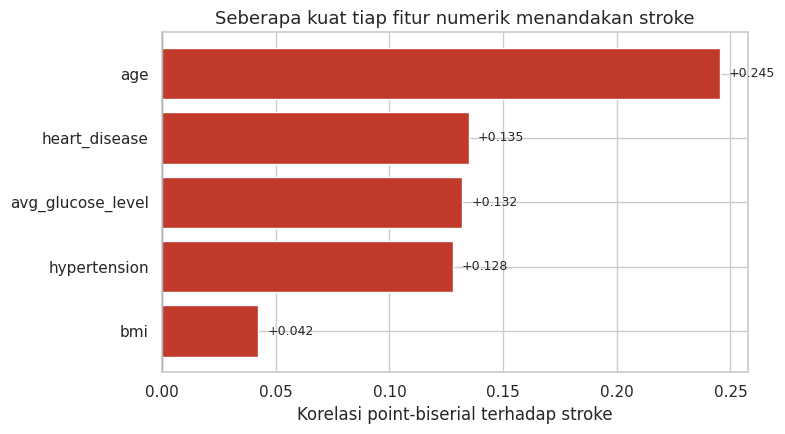

In [ ]:
from scipy.stats import pointbiserialr

fitur_numerik = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]

hasil = []
for kolom in fitur_numerik:
    data = df[[kolom, KOLOM_TARGET]].dropna()
    r, p = pointbiserialr(data[KOLOM_TARGET], data[kolom])
    hasil.append({"fitur": kolom, "r": r, "p_value": p})

tabel_r = pd.DataFrame(hasil).sort_values("r", ascending=False)
print("Korelasi fitur numerik terhadap stroke:")
print(tabel_r.round(4).to_string(index=False))

warna = ["#c0392b" if r > 0 else "#2471a3" for r in tabel_r["r"]]
plt.figure(figsize=(8, 4.5))
plt.barh(tabel_r["fitur"], tabel_r["r"], color=warna)
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.xlabel("Korelasi point-biserial terhadap stroke")
plt.title("Seberapa kuat tiap fitur numerik menandakan stroke")
for i, r in enumerate(tabel_r["r"]):
    plt.text(r + 0.004, i, f"{r:+.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


Kekuatan hubungan fitur kategorikal terhadap stroke:
         fitur    chi2  p_value  cramers_v
  ever_married 58.9239   0.0000     0.1074
     work_type 49.1635   0.0000     0.0981
smoking_status 29.1473   0.0000     0.0755
Residence_type  1.0816   0.2983     0.0145
        gender  0.4726   0.7895     0.0096


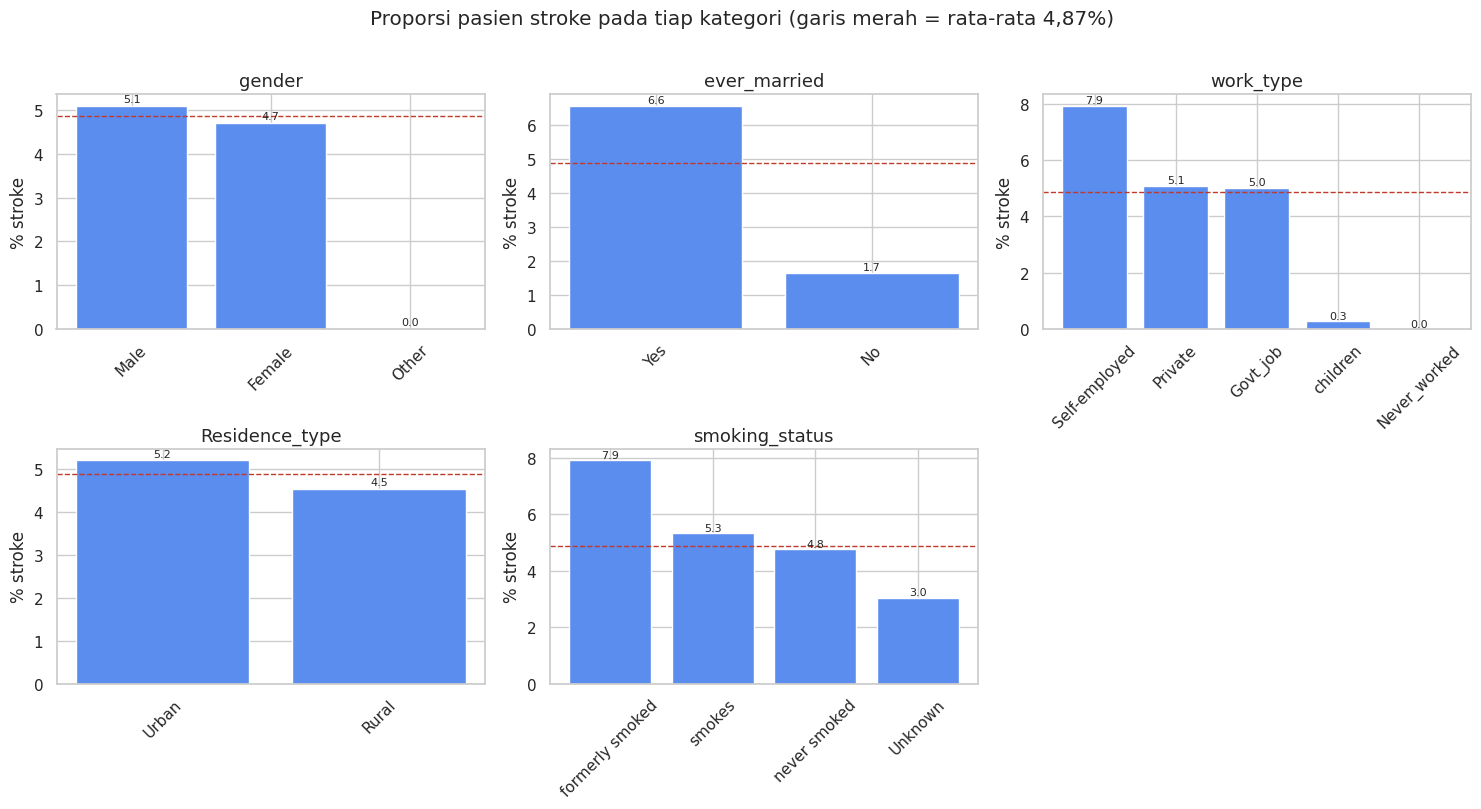

In [ ]:
from scipy.stats import chi2_contingency

fitur_kategorik = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

ringkas = []
for kolom in fitur_kategorik:
    tabel = pd.crosstab(df[kolom], df[KOLOM_TARGET])
    chi2, p, dof, harapan = chi2_contingency(tabel)
    n = tabel.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabel.shape) - 1)))
    ringkas.append({"fitur": kolom, "chi2": chi2, "p_value": p, "cramers_v": v})

tabel_k = pd.DataFrame(ringkas).sort_values("cramers_v", ascending=False)
print("Kekuatan hubungan fitur kategorikal terhadap stroke:")
print(tabel_k.round(4).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, kolom in zip(axes, fitur_kategorik):
    proporsi = (df.groupby(kolom)[KOLOM_TARGET].mean() * 100).sort_values(ascending=False)
    ax.bar(proporsi.index.astype(str), proporsi.values, color="#5b8def")
    ax.axhline(df[KOLOM_TARGET].mean() * 100, color="#c0392b", linestyle="--", linewidth=1)
    ax.set_title(kolom)
    ax.set_ylabel("% stroke")
    ax.tick_params(axis="x", rotation=45)
    for i, vv in enumerate(proporsi.values):
        ax.text(i, vv + 0.08, f"{vv:.1f}", ha="center", fontsize=8)
axes[-1].axis("off")
fig.suptitle("Proporsi pasien stroke pada tiap kategori (garis merah = rata-rata 4,87%)", y=1.01)
plt.tight_layout()
plt.show()


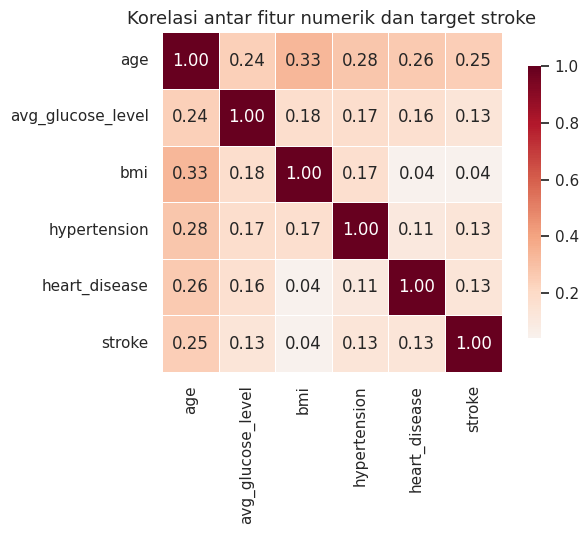

In [ ]:
kolom_korelasi = fitur_numerik + [KOLOM_TARGET]
matriks = df[kolom_korelasi].corr(numeric_only=True)

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    matriks,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Korelasi antar fitur numerik dan target stroke")
plt.tight_layout()
plt.show()


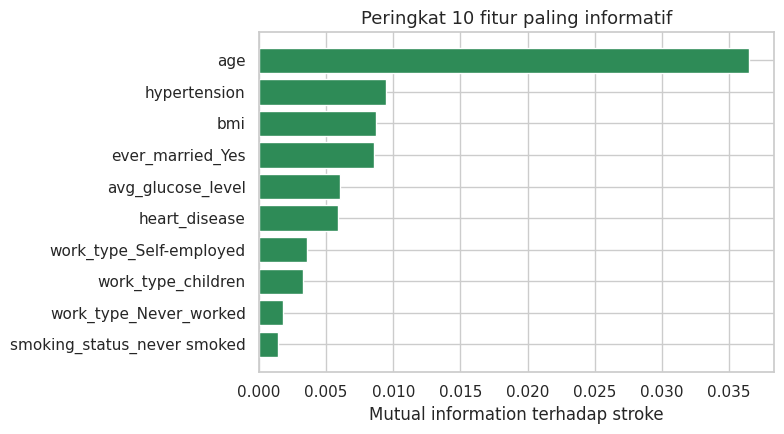

Skor mutual information (10 teratas):
age                            0.0365
hypertension                   0.0095
bmi                            0.0087
ever_married_Yes               0.0086
avg_glucose_level              0.0060
heart_disease                  0.0059
work_type_Self-employed        0.0036
work_type_children             0.0033
work_type_Never_worked         0.0018
smoking_status_never smoked    0.0014


In [ ]:
from sklearn.feature_selection import mutual_info_classif

data_mi = df.drop(columns=[KOLOM_ID]).copy()
data_mi["bmi"] = data_mi["bmi"].fillna(data_mi["bmi"].median())
data_mi = pd.get_dummies(data_mi, drop_first=True)

X_mi = data_mi.drop(columns=[KOLOM_TARGET])
y_mi = data_mi[KOLOM_TARGET]
skor_mi = pd.Series(mutual_info_classif(X_mi, y_mi, random_state=42), index=X_mi.columns)
skor_mi = skor_mi.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4.5))
plt.barh(skor_mi.index[::-1], skor_mi.values[::-1], color="#2e8b57")
plt.xlabel("Mutual information terhadap stroke")
plt.title("Peringkat 10 fitur paling informatif")
plt.tight_layout()
plt.show()

print("Skor mutual information (10 teratas):")
print(skor_mi.round(4).to_string())
